# 01b — Websach Inspection

> **Mục tiêu:** EDA chuyên sâu nguồn Websach (`clean_laptop_features.csv`) — catalog laptop mới từ nhà bán lẻ. Notebook này xác định vấn đề dữ liệu để chuẩn bị cho bước cleaning tại `02b_websach_cleaning.ipynb`.

## Table of Contents

1. [Load & Snapshot](#1-load--snapshot)
2. [Column Inventory & Dtypes](#2-column-inventory--dtypes)
3. [Missing Value Analysis](#3-missing-value-analysis)
4. [Price Analysis (Multi-shop)](#4-price-analysis-multi-shop)
5. [Numeric Columns — Distribution & Outliers](#5-numeric-columns--distribution--outliers)
6. [Categorical Columns — Cardinality & Value Counts](#6-categorical-columns--cardinality--value-counts)
7. [Spec Deep-Dive](#7-spec-deep-dive)
8. [Duplicate Check](#8-duplicate-check)
9. [Issues Summary & Cleaning Checklist](#9-issues-summary--cleaning-checklist)

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:,.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

---
## 1. Load & Snapshot

In [2]:
path_B = r"../../data/raw/clean_laptop_features.csv"
df = pd.read_csv(path_B)

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

Shape: 4,384 rows × 43 columns


,Hãng sản xuất,Hệ điều hành,Chất liệu vỏ,Công nghệ CPU,Loại CPU,Loại RAM,Dung lượng RAM,Tốc độ bus,Hỗ trợ RAM tối đa,Loại ổ cứng,Công nghệ màn hình,Kiểu card đồ họa,Công nghệ âm thanh,Cổng giao tiếp,Kết nối không dây,Webcam,Đèn bàn phím,Loại Pin,Dung lượng,source_url,shop_1_name,shop_1_price,shop_1_link,shop_2_name,shop_2_price,shop_2_link,shop_3_name,shop_3_price,shop_3_link,Khe thẻ nhớ,Tính năng khác,Dung lượng VGA,Dung lượng ổ cứng (GB),Độ phân giải ngang (px),Độ phân giải dọc (px),Kích thước (inch),Trọng lượng (kg),Tốc độ CPU (GHz),Tốc độ tối đa (GHz),Chiều dài (mm),Chiều rộng (mm),Độ dày (mm),Đồ họa đã làm sạch
0,Acer,Windows 10 Home,Nhôm,Intel Core i5,8265U,DDR4,8.00,2666 MHz,20 GB,SSD,"IPS, Acer ComfyView LCD",Card tích hợp,Realtek High Definition,"2x USB 3.1, 1x USB 3.1 Type-C, 1x USB 2.0, HDMI, RJ-45",Wifi 6 AX201 Bluetooth v5.0,HD Webcam,Có,Pin liền,3 cell,https://websosanh.vn/laptop-acer-aspire-a514-53-50p9-nxhussv004-intel-core-i...,baochau.vn,14950000,https://baochau.vn/laptop-acer-aspire-a514-53-50p9-nx-hussv-004-core-i5-1035...,quangmai.net,15950000,https://quangmai.net/san-pham/laptop-acer-aspire-5-a514-53-50p9-nx-hussv-004...,compro.com.vn,"15,990,000.00",http://compro.com.vn/laptop-acer-aspire-5-a514-53-50p9-i5-1035g1.html,NaN,Unknown,NaN,512.00,"1,920.00","1,080.00",14.00,1.50,1.00,3.60,328.80,236.00,17.95,Intel UHD Graphics
1,Lg,Windows 10 Home,Hợp kim,Intel Core i7,1165G7,LPDDR4x,16.00,4266 MHz,NaN,SSD,"Tấm nền IPS, Chống chói Anti-Glare",Card tích hợp,DTS X:Ultra Audio,"2 x Thunderbolt 4 USB-C, 2 x USB 3.2, HDMI","Bluetooth 5.1, Wi-Fi 6 (802.11ax)",HD Webcam,Có,NaN,2 cell,https://websosanh.vn/laptop-lg-gram-17z90p-gah76a5-intel-core-i7-1165g7-16gb...,tiki.vn,32640000,https://fast.accesstrade.com.vn/deep_link/4348611826491973833?url=https%3a%2...,tinhocsangtao.vn,47500000,https://tinhocsangtao.vn/san-pham/laptop-lg-gram-2021-17z90pgah76a5.html,mixicomputer.vn,"35,190,000.00",https://mixicomputer.vn/laptop-lg-gram-17z90p-gah76a5-i7-1165g7-16gb-512gb-s...,Micro SD,"Bảo mật vân tay, Tiêu chuẩn Nền Intel Evo",NaN,512.00,"2,560.00","1,600.00",17.00,1.35,2.80,4.70,380.20,260.10,17.80,Intel Iris Xe
2,Lenovo,Windows 11 Home,NaN,AMD Ryzen 7,8845HS,DDR5,16.00,5600 MHz,32 GB,SSD,"Tấm nền IPS, Chống chói Anti-Glare, 350 nits",Card rời,Nahimic Audio,"USB-A, USB-C, HDMI 2.1","Wifi 802.11ax, Bluetooth 5.3",Full HD Webcam,Có,NaN,4 cell,https://websosanh.vn/laptop-lenovo-gaming-legion-slim-5-16ahp9-83dh003avn-am...,congnghesgsaigon.com,30900000,https://congnghesgsaigon.com/laptop-lenovo-legion-slim-5-16ahp9-83dh003avn-r...,tnc.com.vn,31490000,https://www.tnc.com.vn/laptop-lenovo-legion-slim-5-16ahp9-r7-83dh003avn.html,tymo.vn,"33,490,000.00",https://tymo.vn/san-pham/laptop-lenovo-legion-slim-5-16ahp9-83dh003avn-ryzen...,SD,Bảo mật vân tay,8 GB,512.00,"2,560.00","1,600.00",16.00,2.30,3.80,5.10,359.70,260.50,19.90,RTX 4060


In [3]:
# Quick info — dtypes và non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 43 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Hãng sản xuất            4204 non-null   object 
 1   Hệ điều hành             4384 non-null   object 
 2   Chất liệu vỏ             2169 non-null   object 
 3   Công nghệ CPU            4290 non-null   object 
 4   Loại CPU                 4315 non-null   object 
 5   Loại RAM                 4066 non-null   object 
 6   Dung lượng RAM           4363 non-null   float64
 7   Tốc độ bus               3877 non-null   object 
 8   Hỗ trợ RAM tối đa        1910 non-null   object 
 9   Loại ổ cứng              4165 non-null   object 
 10  Công nghệ màn hình       4147 non-null   object 
 11  Kiểu card đồ họa         4215 non-null   object 
 12  Công nghệ âm thanh       4384 non-null   object 
 13  Cổng giao tiếp           4357 non-null   object 
 14  Kết nối không dây       

---
## 2. Column Inventory & Dtypes

Websach có **43 cột** trải rộng nhiều nhóm thông tin. Phân loại theo nhóm để dễ kiểm tra.

In [4]:
# Tổng quan dtypes
dtype_summary = df.dtypes.value_counts()
print("Dtype distribution:")
print(dtype_summary)

# Liệt kê tất cả cột theo nhóm
col_groups = {
    "Nhận diện": ['Hãng sản xuất', 'source_url'],
    "CPU": ['Công nghệ CPU', 'Loại CPU', 'Tốc độ CPU (GHz)', 'Tốc độ tối đa (GHz)'],
    "RAM": ['Loại RAM', 'Dung lượng RAM', 'Tốc độ bus', 'Hỗ trợ RAM tối đa'],
    "Ổ cứng": ['Loại ổ cứng', 'Dung lượng ổ cứng (GB)', 'Dung lượng'],
    "Màn hình": ['Công nghệ màn hình', 'Kích thước (inch)', 'Độ phân giải ngang (px)', 'Độ phân giải dọc (px)'],
    "Card đồ họa": ['Kiểu card đồ họa', 'Dung lượng VGA', 'Đồ họa đã làm sạch'],
    "Vật lý": ['Trọng lượng (kg)', 'Chiều dài (mm)', 'Chiều rộng (mm)', 'Độ dày (mm)', 'Chất liệu vỏ'],
    "Kết nối": ['Cổng giao tiếp', 'Kết nối không dây', 'Webcam', 'Đèn bàn phím', 'Khe thẻ nhớ'],
    "Hệ thống": ['Hệ điều hành', 'Loại Pin', 'Công nghệ âm thanh', 'Tính năng khác'],
    "Giá (multi-shop)": [
        'shop_1_name', 'shop_1_price', 'shop_1_link',
        'shop_2_name', 'shop_2_price', 'shop_2_link',
        'shop_3_name', 'shop_3_price', 'shop_3_link',
    ],
}

# Kiểm tra xem có cột nào chưa được nhóm không
all_grouped = [c for cols in col_groups.values() for c in cols]
ungrouped = [c for c in df.columns if c not in all_grouped]
if ungrouped:
    print(f"\n⚠️  Cột chưa được nhóm: {ungrouped}")

print("\nColumn groups:")
for group, cols in col_groups.items():
    existing = [c for c in cols if c in df.columns]
    print(f"  [{group}]: {existing}")

Dtype distribution:
object     29
float64    12
int64       2
Name: count, dtype: int64

Column groups:
  [Nhận diện]: ['Hãng sản xuất', 'source_url']
  [CPU]: ['Công nghệ CPU', 'Loại CPU', 'Tốc độ CPU (GHz)', 'Tốc độ tối đa (GHz)']
  [RAM]: ['Loại RAM', 'Dung lượng RAM', 'Tốc độ bus', 'Hỗ trợ RAM tối đa']
  [Ổ cứng]: ['Loại ổ cứng', 'Dung lượng ổ cứng (GB)', 'Dung lượng']
  [Màn hình]: ['Công nghệ màn hình', 'Kích thước (inch)', 'Độ phân giải ngang (px)', 'Độ phân giải dọc (px)']
  [Card đồ họa]: ['Kiểu card đồ họa', 'Dung lượng VGA', 'Đồ họa đã làm sạch']
  [Vật lý]: ['Trọng lượng (kg)', 'Chiều dài (mm)', 'Chiều rộng (mm)', 'Độ dày (mm)', 'Chất liệu vỏ']
  [Kết nối]: ['Cổng giao tiếp', 'Kết nối không dây', 'Webcam', 'Đèn bàn phím', 'Khe thẻ nhớ']
  [Hệ thống]: ['Hệ điều hành', 'Loại Pin', 'Công nghệ âm thanh', 'Tính năng khác']
  [Giá (multi-shop)]: ['shop_1_name', 'shop_1_price', 'shop_1_link', 'shop_2_name', 'shop_2_price', 'shop_2_link', 'shop_3_name', 'shop_3_price', 'shop_3_link

---
## 3. Missing Value Analysis

Websach có nhiều trường spec tùy chọn — missing có thể mang ý nghĩa khác nhau (không công bố, không có tính năng, lỗi crawl).

In [5]:
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)
miss_report = pd.DataFrame({'Missing': miss, 'Missing %': miss_pct})
miss_report = miss_report[miss_report['Missing'] > 0].sort_values('Missing %', ascending=False)

print(f"Tổng số cột có missing: {len(miss_report)} / {df.shape[1]}")
display(miss_report)

Tổng số cột có missing: 30 / 43


,Missing,Missing %
Loại Pin,3036,69.30
Dung lượng VGA,2916,66.50
Hỗ trợ RAM tối đa,2474,56.40
Chất liệu vỏ,2215,50.50
Khe thẻ nhớ,2156,49.20
Dung lượng,650,14.80
Tốc độ CPU (GHz),635,14.50
Tốc độ bus,507,11.60
Chiều rộng (mm),456,10.40
Chiều dài (mm),456,10.40


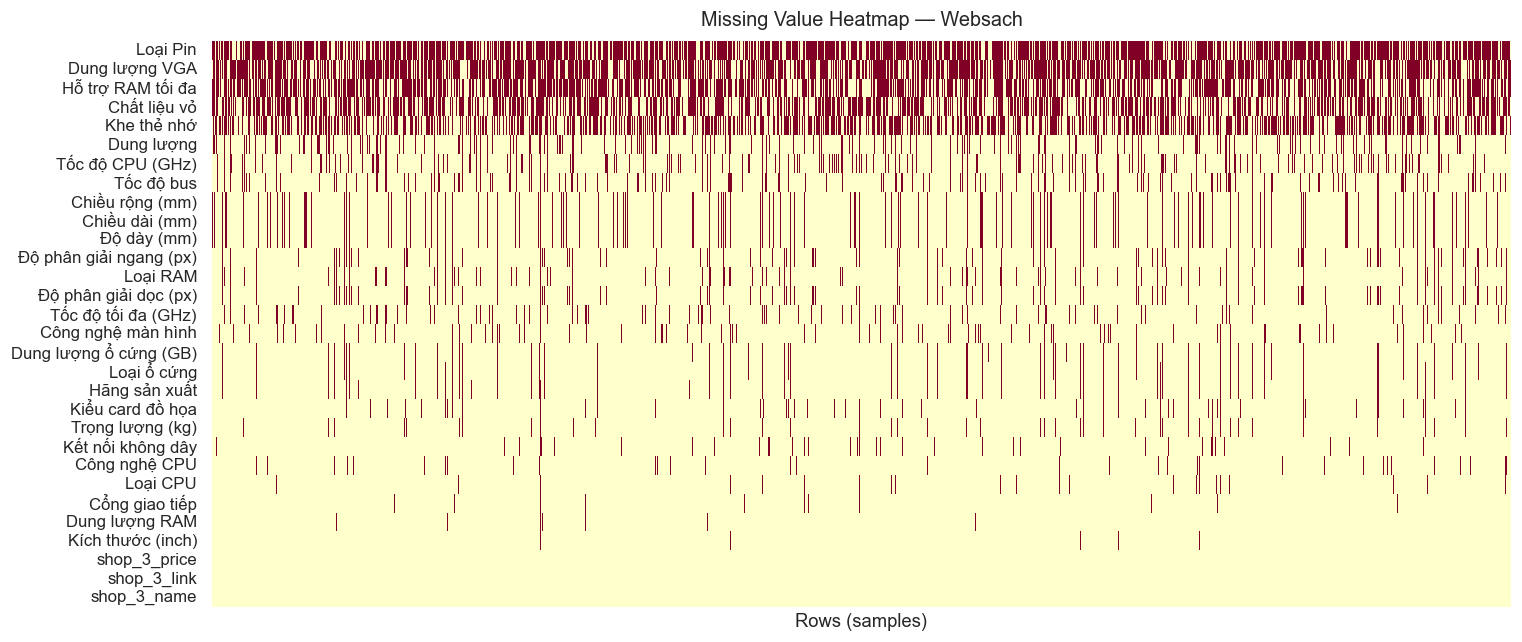

In [6]:
# Heatmap missing — nhóm các cột liên quan
cols_with_missing = miss_report.index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    df[cols_with_missing].isnull().T,
    cbar=False, yticklabels=True, xticklabels=False,
    cmap='YlOrRd', ax=ax
)
ax.set_title('Missing Value Heatmap — Websach', fontsize=13, pad=10)
ax.set_xlabel('Rows (samples)')
plt.tight_layout()
plt.show()

In [7]:
# Phân loại mức độ missing
def classify_missing(pct):
    if pct == 0: return 'Complete'
    elif pct < 10: return 'Low (<10%)'
    elif pct < 30: return 'Medium (10–30%)'
    elif pct < 60: return 'High (30–60%)'
    else: return 'Critical (>60%)'

miss_report['Level'] = miss_report['Missing %'].apply(classify_missing)
print(miss_report.groupby('Level')['Missing %'].count().rename('# Columns'))

Level
Complete            3
Critical (>60%)     2
High (30–60%)       3
Low (<10%)         16
Medium (10–30%)     6
Name: # Columns, dtype: int64


---
## 4. Price Analysis (Multi-shop)

Websach cung cấp giá từ tối đa **3 shop** cho cùng một model. Cần xác định:
- Bao nhiêu sản phẩm có đủ 1/2/3 giá?
- Phân phối giá theo từng shop
- Outlier giá bất thường
- Chiến lược chọn `price` đại diện cho bước merge

In [8]:
price_cols = ['shop_1_price', 'shop_2_price', 'shop_3_price']

# Số lượng sản phẩm có giá theo từng shop
for col in price_cols:
    if col in df.columns:
        n_valid = df[col].notna().sum()
        print(f"{col}: {n_valid:,} / {len(df):,} ({n_valid/len(df)*100:.1f}%)")

shop_1_price: 4,384 / 4,384 (100.0%)
shop_2_price: 4,384 / 4,384 (100.0%)
shop_3_price: 4,382 / 4,384 (100.0%)


In [9]:
# Phân phối số shop có giá cho mỗi sản phẩm
# Tính trên biến tạm, không mutate df gốc
n_prices_series = df[price_cols].notna().sum(axis=1)
print("Số shop có giá / sản phẩm:")
print(n_prices_series.value_counts().sort_index())


Số shop có giá / sản phẩm:
2       2
3    4382
Name: count, dtype: int64


In [10]:
# Tính giá đại diện: median của các giá có sẵn
# Dùng biến tạm để không ô nhiễm df gốc
price_median = df[price_cols].median(axis=1)
price_min    = df[price_cols].min(axis=1)
price_max    = df[price_cols].max(axis=1)
price_spread = price_max - price_min  # chênh lệch giữa các shop

print("Thống kê price_median (triệu VNĐ):")
print((price_median / 1e6).describe().round(2))


Thống kê price_median (triệu VNĐ):
count   4,384.00
mean       26.03
std        17.39
min         3.47
25%        15.20
50%        21.19
75%        30.99
max       179.40
dtype: float64


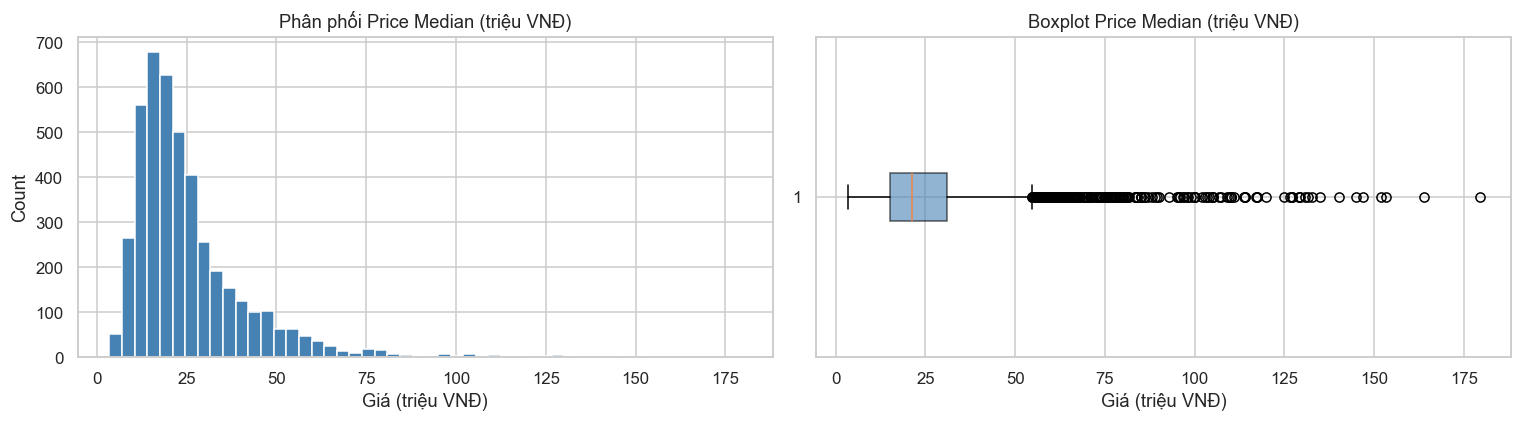

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram phân phối giá median
axes[0].hist(price_median.dropna() / 1e6, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Phân phối Price Median (triệu VNĐ)')
axes[0].set_xlabel('Giá (triệu VNĐ)')
axes[0].set_ylabel('Count')

# Boxplot để phát hiện outlier
axes[1].boxplot(price_median.dropna() / 1e6, vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot Price Median (triệu VNĐ)')
axes[1].set_xlabel('Giá (triệu VNĐ)')

plt.tight_layout()
plt.show()


In [12]:
# Outlier giá cực đoan
q1 = price_median.quantile(0.25)
q3 = price_median.quantile(0.75)
iqr = q3 - q1
lower = q1 - 3 * iqr
upper = q3 + 3 * iqr

outliers_price = df[(price_median < lower) | (price_median > upper)]
print(f"Ngưỡng IQR×3: [{lower/1e6:.1f}M, {upper/1e6:.1f}M]")
print(f"Số outlier giá: {len(outliers_price)}")

if len(outliers_price) > 0:
    display(outliers_price[['Hãng sản xuất', 'shop_1_price', 'shop_2_price', 'shop_3_price']].head(10))


Ngưỡng IQR×3: [-32.2M, 78.4M]
Số outlier giá: 82


,Hãng sản xuất,shop_1_price,shop_2_price,shop_3_price
5,NaN,96599000,98190000,"101,990,000.00"
19,Apple,99990000,109000000,"111,990,000.00"
75,Hp,127000000,136263000,"124,999,000.00"
144,Msi,85990000,82990000,"85,890,000.00"
169,Msi,94990000,95990000,"99,990,000.00"
263,Msi,82899000,83490000,"86,490,000.00"
378,Apple,104990000,106800000,"106,990,000.00"
523,Msi,88500000,92990000,"92,999,000.00"
597,Lenovo,64550000,80490000,"81,900,000.00"
602,Apple,176990000,179400000,"181,740,000.00"


In [13]:
# Spread giá giữa các shop — phân tích chênh lệch
print("Chênh lệch giá giữa các shop (price_spread, triệu VNĐ):")
print((price_spread.dropna() / 1e6).describe().round(2))

# Sản phẩm có chênh lệch giá lớn bất thường
large_spread_mask = price_spread > price_spread.quantile(0.95)
large_spread = df[large_spread_mask]
print(f"\nSản phẩm có spread giá > P95: {len(large_spread)}")
if len(large_spread) > 0:
    tmp = large_spread[['Hãng sản xuất', 'shop_1_price', 'shop_2_price', 'shop_3_price']].copy()
    tmp['price_spread'] = price_spread[large_spread_mask]
    display(tmp.head(5))


Chênh lệch giá giữa các shop (price_spread, triệu VNĐ):
count   4,384.00
mean        4.96
std        49.50
min         0.00
25%         0.97
50%         2.20
75%         4.89
max     2,707.81
dtype: float64

Sản phẩm có spread giá > P95: 220


,Hãng sản xuất,shop_1_price,shop_2_price,shop_3_price,price_spread
1,Lg,32640000,47500000,"35,190,000.00","14,860,000.00"
6,Lenovo,31490000,43900000,"44,490,000.00","13,000,000.00"
19,Apple,99990000,109000000,"111,990,000.00","12,000,000.00"
20,Samsung,28500000,38990000,"47,900,000.00","19,400,000.00"
40,Msi,59990000,71250000,"71,890,000.00","11,900,000.00"


In [14]:
# Giá theo hãng
if 'Hãng sản xuất' in df.columns:
    tmp_df = df[['Hãng sản xuất']].copy()
    tmp_df['price_median'] = price_median
    price_by_brand = (
        tmp_df.groupby('Hãng sản xuất')['price_median']
        .agg(['median', 'count'])
        .rename(columns={'median': 'Median Price', 'count': 'Count'})
        .sort_values('Median Price', ascending=False)
    )
    price_by_brand['Median Price (M)'] = (price_by_brand['Median Price'] / 1e6).round(2)
    display(price_by_brand.head(20).style.background_gradient(subset=['Median Price (M)'], cmap='Blues'))


,Median Price,Count,Median Price (M)
Hãng sản xuất,,,
Aorus,58190000.000000,2,58.190000
Apple,42240000.000000,146,42.240000
Razer,40990000.000000,1,40.990000
Microsoft,32499000.000000,89,32.500000
Surface,30590000.000000,14,30.590000
Gigabyte,29994500.000000,56,29.990000
Lg,29199000.000000,33,29.200000
Samsung,29195000.000000,14,29.200000
Xpg,28989000.000000,1,28.990000


---
## 5. Numeric Columns — Distribution & Outliers

Websach có nhiều cột đã được parse thành `float64`. Kiểm tra phân phối và outlier cho từng cột số quan trọng.

In [15]:
# Lấy tất cả cột số (trừ giá shop)
exclude_num = ['shop_1_price', 'shop_2_price', 'shop_3_price']

num_cols = [c for c in df.select_dtypes(include='number').columns if c not in exclude_num]
print(f"Numeric columns (non-price): {num_cols}")
display(df[num_cols].describe().T.style.background_gradient(cmap='Blues'))


Numeric columns (non-price): ['Dung lượng RAM', 'Dung lượng ổ cứng (GB)', 'Độ phân giải ngang (px)', 'Độ phân giải dọc (px)', 'Kích thước (inch)', 'Trọng lượng (kg)', 'Tốc độ CPU (GHz)', 'Tốc độ tối đa (GHz)', 'Chiều dài (mm)', 'Chiều rộng (mm)', 'Độ dày (mm)']


,count,mean,std,min,25%,50%,75%,max
Dung lượng RAM,4363.000000,16.066468,85.735942,2.000000,8.000000,16.000000,16.000000,5600.000000
Dung lượng ổ cứng (GB),4159.000000,647.924501,432.221002,16.000000,512.000000,512.000000,1024.000000,8192.000000
Độ phân giải ngang (px),4064.000000,2071.083169,447.606672,920.000000,1920.000000,1920.000000,1920.000000,3840.000000
Độ phân giải dọc (px),4064.000000,1227.213091,314.419010,108.000000,1080.000000,1080.000000,1200.000000,2400.000000
Kích thước (inch),4373.000000,21.340334,46.632072,2.140000,14.000000,15.600000,15.600000,398.000000
Trọng lượng (kg),4237.000000,2.145399,18.338330,0.000000,1.400000,1.650000,1.990000,1112.000000
Tốc độ CPU (GHz),3749.000000,2.514396,8.619530,0.900000,1.700000,2.200000,2.600000,400.000000
Tốc độ tối đa (GHz),4075.000000,4.472226,0.567618,1.830000,4.200000,4.600000,4.800000,5.800000
Chiều dài (mm),3928.000000,341.349356,124.236247,24.500000,315.975000,342.000000,359.200000,3820.000000
Chiều rộng (mm),3928.000000,233.655739,57.466187,17.500000,220.000000,233.700000,251.000000,2630.000000


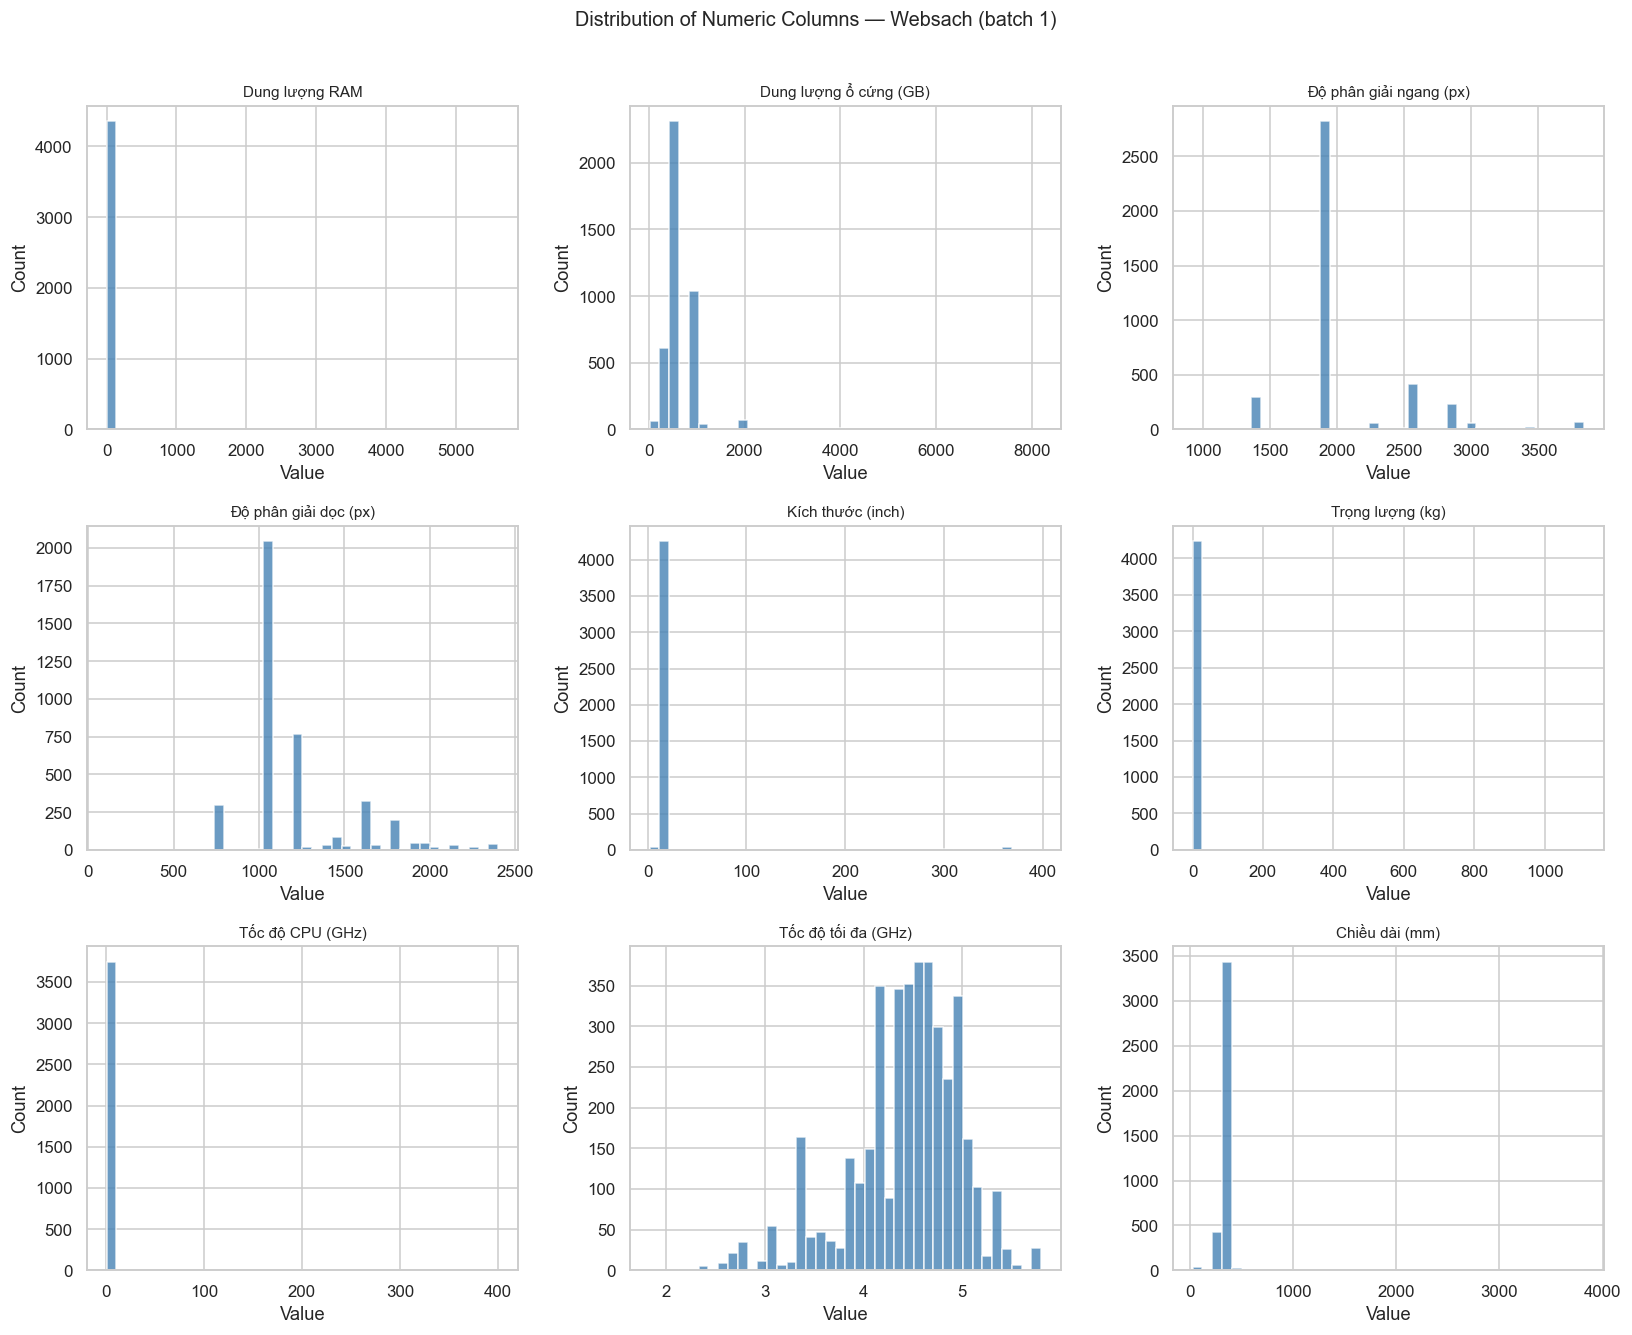

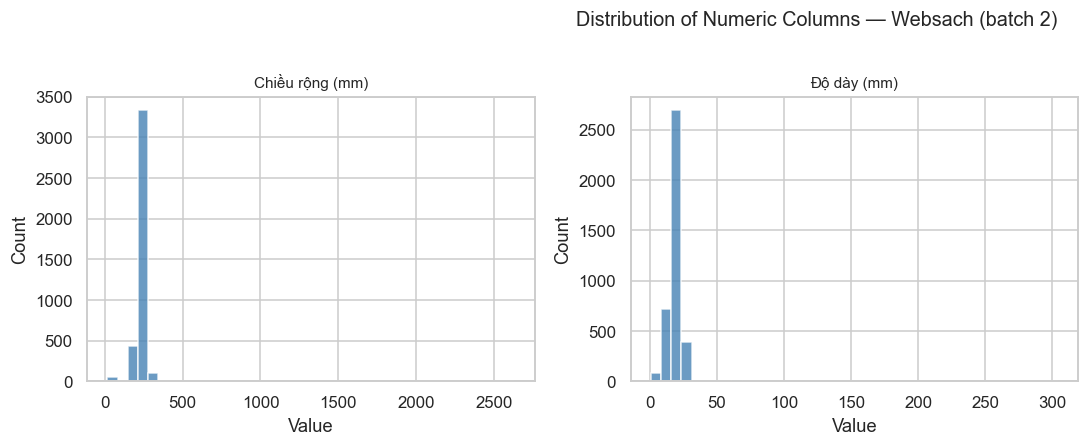

In [16]:
# Histogram grid cho các cột số — chia batch nếu nhiều cột
key_num_cols = [c for c in num_cols if c in df.columns]
BATCH_SIZE = 9
n_cols_per_row = 3

for batch_start in range(0, len(key_num_cols), BATCH_SIZE):
    batch = key_num_cols[batch_start:batch_start + BATCH_SIZE]
    n_rows = -(-len(batch) // n_cols_per_row)  # ceiling division
    fig, axes = plt.subplots(n_rows, n_cols_per_row, figsize=(15, 4 * n_rows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for i, col in enumerate(batch):
        data = df[col].dropna()
        axes[i].hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
        axes[i].set_title(col, fontsize=10)
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Count')

    for j in range(len(batch), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(
        f'Distribution of Numeric Columns — Websach (batch {batch_start//BATCH_SIZE + 1})',
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    plt.show()


In [17]:
# Phát hiện outlier cho các cột số bằng IQR
def iqr_outliers(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    mask = (series < lo) | (series > hi)
    return mask.sum(), lo, hi

print(f"{'Column':<35} {'N outliers':>12} {'IQR lower':>12} {'IQR upper':>12}")
print('-' * 75)
for col in num_cols:
    if df[col].notna().sum() > 10:
        n_out, lo, hi = iqr_outliers(df[col].dropna())
        print(f"{col:<35} {n_out:>12,} {lo:>12.2f} {hi:>12.2f}")

Column                                N outliers    IQR lower    IQR upper
---------------------------------------------------------------------------
Dung lượng RAM                               590        -4.00        28.00
Dung lượng ổ cứng (GB)                        89      -256.00      1792.00
Độ phân giải ngang (px)                    1,240      1920.00      1920.00
Độ phân giải dọc (px)                      1,213       900.00      1380.00
Kích thước (inch)                            121        11.60        18.00
Trọng lượng (kg)                              68         0.51         2.88
Tốc độ CPU (GHz)                              31         0.35         3.95
Tốc độ tối đa (GHz)                          187         3.30         5.70
Chiều dài (mm)                                77       251.14       424.04
Chiều rộng (mm)                              100       173.50       297.50
Độ dày (mm)                                  260        10.63        27.34


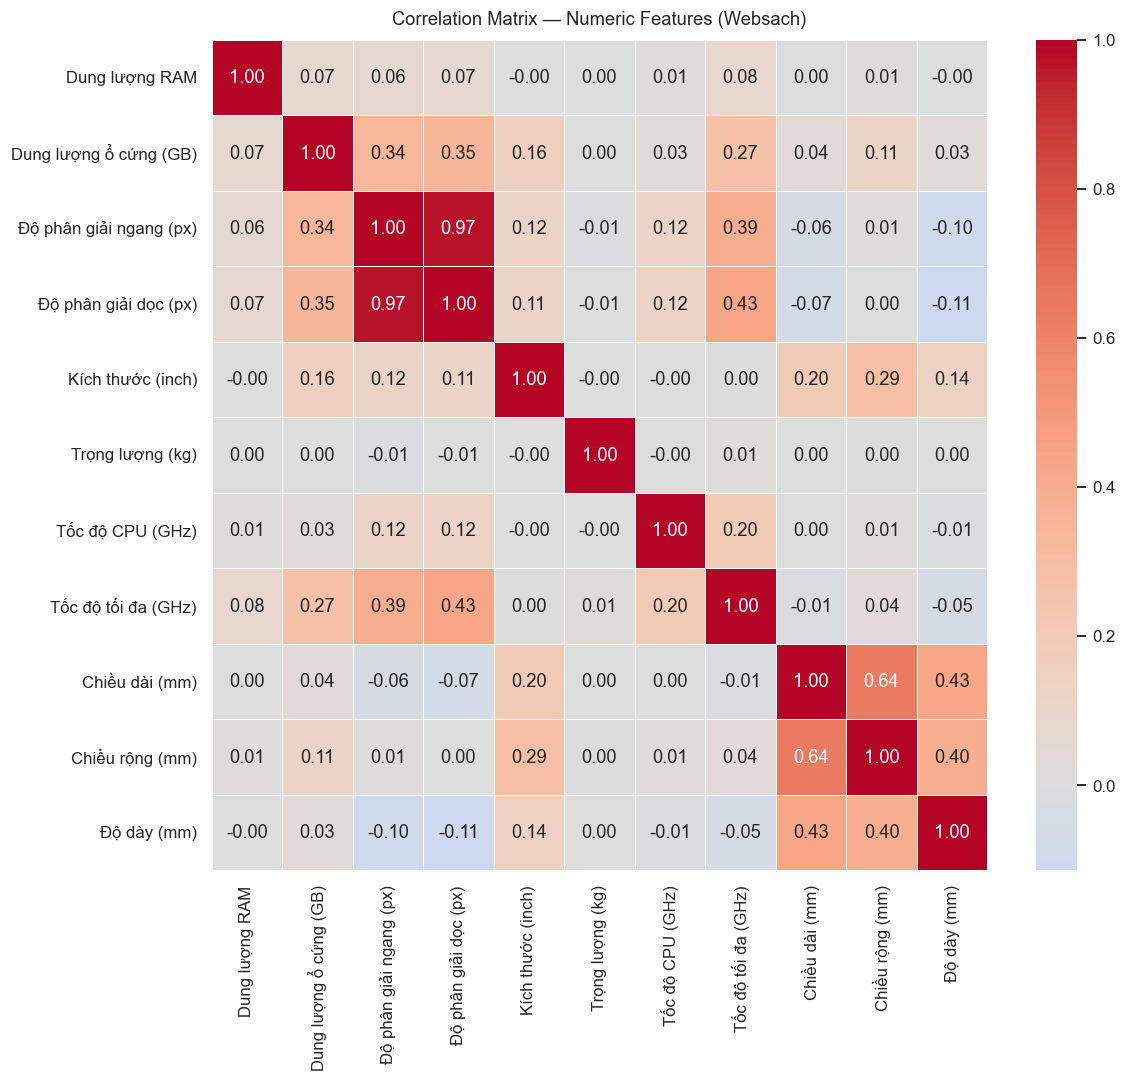

In [18]:
# Correlation heatmap — phát hiện multicollinearity giữa numeric features
if len(num_cols) >= 2:
    corr = df[num_cols].corr()
    fig, ax = plt.subplots(figsize=(max(8, len(num_cols)), max(6, len(num_cols)-1)))
    sns.heatmap(
        corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
        linewidths=0.5, ax=ax
    )
    ax.set_title('Correlation Matrix — Numeric Features (Websach)', fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()


In [19]:
# Spotlight: Trọng lượng — outlier đã được note trong overview (max 1112 kg)
if 'Trọng lượng (kg)' in df.columns:
    wt = df['Trọng lượng (kg)']
    print("Trọng lượng (kg) — describe:")
    print(wt.describe())
    print(f"\nGiá trị cực đoan (> 10 kg):\n{df[wt > 10][['Hãng sản xuất', 'Trọng lượng (kg)']]}")

Trọng lượng (kg) — describe:
count   4,237.00
mean        2.15
std        18.34
min         0.00
25%         1.40
50%         1.65
75%         1.99
max     1,112.00
Name: Trọng lượng (kg), dtype: float64

Giá trị cực đoan (> 10 kg):
     Hãng sản xuất  Trọng lượng (kg)
310             Lg          1,112.00
655             Hp            256.00
1935            Hp             13.90
2051        Lenovo             11.34
2419          Asus            357.20
2519           Msi             22.50


In [20]:
# Spotlight: Kích thước màn hình
if 'Kích thước (inch)' in df.columns:
    sz = df['Kích thước (inch)']
    print("Kích thước màn hình (inch) — describe:")
    print(sz.describe())
    print(f"\nGiá trị cực đoan (> 25 inch):\n{df[sz > 25][['Hãng sản xuất', 'Kích thước (inch)']]}")

Kích thước màn hình (inch) — describe:
count   4,373.00
mean       21.34
std        46.63
min         2.14
25%        14.00
50%        15.60
75%        15.60
max       398.00
Name: Kích thước (inch), dtype: float64

Giá trị cực đoan (> 25 inch):
     Hãng sản xuất  Kích thước (inch)
5              NaN             380.00
17             NaN             304.10
22            Asus             355.30
37             NaN             357.00
173            NaN             359.40
...            ...                ...
4124           NaN             364.00
4185          Asus             359.70
4229           NaN             398.00
4301          Asus             395.00
4305           NaN             359.00

[85 rows x 2 columns]


In [21]:
# Spotlight: CPU speed
for col in ['Tốc độ CPU (GHz)', 'Tốc độ tối đa (GHz)']:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].describe())
        extreme = df[df[col] > 10]
        if len(extreme) > 0:
            print(f"  ⚠️  {len(extreme)} rows với {col} > 10 GHz")


Tốc độ CPU (GHz):
count   3,749.00
mean        2.51
std         8.62
min         0.90
25%         1.70
50%         2.20
75%         2.60
max       400.00
Name: Tốc độ CPU (GHz), dtype: float64
  ⚠️  6 rows với Tốc độ CPU (GHz) > 10 GHz

Tốc độ tối đa (GHz):
count   4,075.00
mean        4.47
std         0.57
min         1.83
25%         4.20
50%         4.60
75%         4.80
max         5.80
Name: Tốc độ tối đa (GHz), dtype: float64


---
## 6. Categorical Columns — Cardinality & Value Counts

Kiểm tra các cột `object` — cardinality, giá trị phổ biến, và các vấn đề tiềm ẩn (trailing spaces, case inconsistency, mixed formats).

In [22]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
# Loại bỏ URL columns
cat_cols_clean = [c for c in cat_cols if 'url' not in c.lower() and 'link' not in c.lower()]

def safe_top(series):
    vc = series.value_counts()
    return (vc.index[0], vc.iloc[0]) if len(vc) > 0 else (None, 0)

cardinality = pd.DataFrame({
    'Unique':      [df[c].nunique() for c in cat_cols_clean],
    'Non-null':    [df[c].notna().sum() for c in cat_cols_clean],
    'Top 1':       [safe_top(df[c].dropna())[0] for c in cat_cols_clean],
    'Top 1 Count': [safe_top(df[c].dropna())[1] for c in cat_cols_clean],
}, index=cat_cols_clean).sort_values('Unique', ascending=False)

display(cardinality)


,Unique,Non-null,Top 1,Top 1 Count
Cổng giao tiếp,2751,4357,"USB-A, USB-C, HDMI 2.1",72
Công nghệ màn hình,1426,4147,"Tấm nền IPS, Chống chói Anti-Glare",572
Kết nối không dây,671,4278,"Wifi 802.11ax, Bluetooth 5.2",586
shop_3_name,627,4382,eaz.com.vn,307
shop_2_name,573,4384,eaz.com.vn,408
shop_1_name,496,4384,eaz.com.vn,349
Loại CPU,390,4315,1135G7,235
Công nghệ âm thanh,373,4384,Unknown,1641
Tính năng khác,230,4384,Unknown,2205
Webcam,190,4384,HD Webcam,1943


Hãng sản xuất — value counts:
Hãng sản xuất
Hp           832
Dell         805
Lenovo       802
Asus         801
Acer         314
Msi          275
Apple        146
Microsoft     89
Gigabyte      56
Lg            33
Surface       14
Samsung       14
Toshiba        4
Vaio           3
Xiaomi         3
Avita          3
Masstel        2
Aorus          2
Razer          1
Mechrevo       1
Intel          1
Xpg            1
Chuwi          1
Fujitsu        1
Name: count, dtype: int64


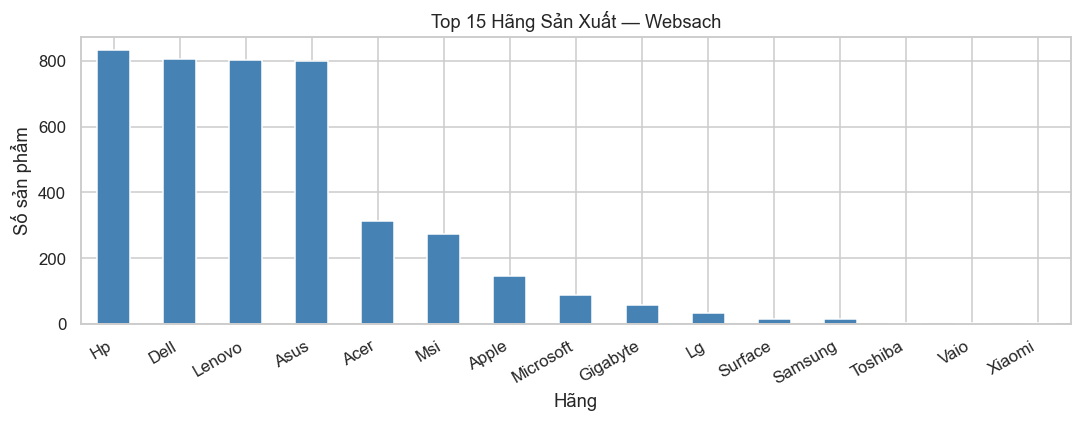

In [23]:
# Hãng sản xuất — phân phối
if 'Hãng sản xuất' in df.columns:
    brand_counts = df['Hãng sản xuất'].value_counts()
    print("Hãng sản xuất — value counts:")
    print(brand_counts)

    fig, ax = plt.subplots(figsize=(10, 4))
    brand_counts.head(15).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Top 15 Hãng Sản Xuất — Websach')
    ax.set_xlabel('Hãng')
    ax.set_ylabel('Số sản phẩm')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

In [24]:
# Kiểm tra trailing space / case inconsistency trong các cột categorical
issues_case = {}
for col in cat_cols_clean:
    if df[col].notna().any():
        raw = df[col].dropna()
        stripped = raw.str.strip()
        n_trailing = (raw != stripped).sum()
        if n_trailing > 0:
            issues_case[col] = n_trailing

if issues_case:
    print("Cột có trailing whitespace:")
    for col, cnt in issues_case.items():
        print(f"  {col}: {cnt} rows")
else:
    print("✅ Không phát hiện trailing whitespace trong categorical columns")

✅ Không phát hiện trailing whitespace trong categorical columns


In [25]:
# Deep dive các cột categorical quan trọng
important_cats = [
    'Công nghệ CPU', 'Loại CPU', 'Loại RAM',
    'Loại ổ cứng', 'Công nghệ màn hình',
    'Kiểu card đồ họa', 'Hệ điều hành',
]

for col in important_cats:
    if col in df.columns and df[col].notna().any():
        print(f"\n{'='*50}")
        print(f"{col} ({df[col].nunique()} unique values):")
        print(df[col].value_counts().head(15).to_string())


Công nghệ CPU (126 unique values):
Công nghệ CPU
Intel Core i5         1281
Intel Core i7          908
Intel Core i3          375
Intel Core Ultra 7     232
AMD Ryzen 7            214
AMD Ryzen 5            195
Intel Core Ultra 5     172
Intel Core i9           87
Intel Core Ultra 9      68
Intel core i7           57
Intel Core 5            54
AMD Ryzen 9             51
Intel Core 7            40
Intel core i5           32
AMD Ryzen 3             31

Loại CPU (390 unique values):
Loại CPU
1135G7    235
1235U     129
1355U     103
1165G7    101
155H       99
8265U      97
1335U      96
8250U      90
1115G4     80
13620H     74
13420H     71
125H       65
1255U      62
12700H     60
11800H     57

Loại RAM (29 unique values):
Loại RAM
DDR4       2112
DDR5       1119
LPDDR5x     251
LPDDR5      241
LPDDR4x      87
DDR3L        62
DDR3         60
LPDDR3       43
LPDDR5X      41
LPDDR4       14
16            5
DR4           4
DDR5x         3
DDR5X         3
LDDR3         2

Loại ổ cứng (9 

---
## 7. Spec Deep-Dive

Phân tích kỹ các spec kỹ thuật quan trọng — đây là điểm mạnh của nguồn Websach so với Chợ Tốt.

### 7.1 RAM

Dung lượng RAM — dtype: float64
Dung lượng RAM
16.00       1648
8.00        1448
4.00         595
32.00        507
24.00         58
64.00         52
128.00        12
36.00          9
12.00          9
2.00           6
48.00          5
5.00           3
96.00          2
18.00          2
15.00          2
19.00          1
192.00         1
512.00         1
5,600.00       1
6.00           1
Name: count, dtype: int64


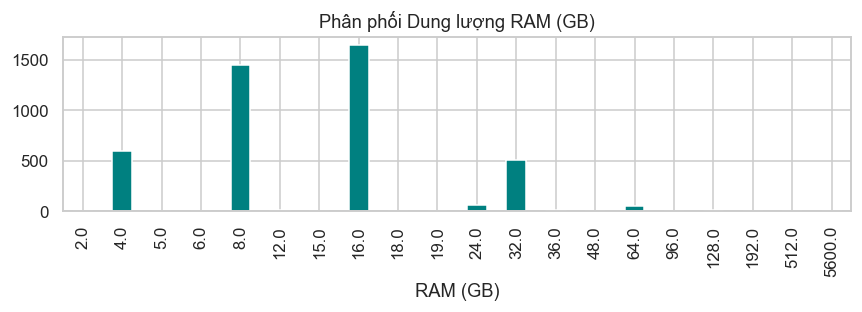

In [26]:
ram_col = 'Dung lượng RAM'
if ram_col in df.columns:
    print(f"{ram_col} — dtype: {df[ram_col].dtype}")
    print(df[ram_col].value_counts().head(20))

    # Nếu là float — vẽ histogram
    if df[ram_col].dtype in ['float64', 'int64']:
        fig, ax = plt.subplots(figsize=(8, 3))
        df[ram_col].dropna().value_counts().sort_index().plot(kind='bar', ax=ax, color='teal', edgecolor='white')
        ax.set_title('Phân phối Dung lượng RAM (GB)')
        ax.set_xlabel('RAM (GB)')
        plt.tight_layout()
        plt.show()

### 7.2 Ổ cứng

In [27]:
storage_col = 'Dung lượng ổ cứng (GB)'
if storage_col in df.columns:
    print(f"{storage_col} — describe:")
    print(df[storage_col].describe())

# Cột 'Dung lượng' (raw string) — xem thử format
if 'Dung lượng' in df.columns:
    print("\nDung lượng (raw) — sample values:")
    print(df['Dung lượng'].value_counts().head(20))

Dung lượng ổ cứng (GB) — describe:
count   4,159.00
mean      647.92
std       432.22
min        16.00
25%       512.00
50%       512.00
75%     1,024.00
max     8,192.00
Name: Dung lượng ổ cứng (GB), dtype: float64

Dung lượng (raw) — sample values:
Dung lượng
3 cell                   2074
4 cell                   1286
2 cell                    195
6 cell                    169
8 cell                      6
57Wh cell                   1
9 cell                      1
1.44 cell                   1
327 x 225 x 17.5 cell       1
Name: count, dtype: int64


### 7.3 Màn hình

In [28]:
screen_cols = ['Kích thước (inch)', 'Độ phân giải ngang (px)', 'Độ phân giải dọc (px)']
for col in screen_cols:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].describe())


Kích thước (inch):
count   4,373.00
mean       21.34
std        46.63
min         2.14
25%        14.00
50%        15.60
75%        15.60
max       398.00
Name: Kích thước (inch), dtype: float64

Độ phân giải ngang (px):
count   4,064.00
mean    2,071.08
std       447.61
min       920.00
25%     1,920.00
50%     1,920.00
75%     1,920.00
max     3,840.00
Name: Độ phân giải ngang (px), dtype: float64

Độ phân giải dọc (px):
count   4,064.00
mean    1,227.21
std       314.42
min       108.00
25%     1,080.00
50%     1,080.00
75%     1,200.00
max     2,400.00
Name: Độ phân giải dọc (px), dtype: float64


In [29]:
# Tạo cột resolution string — tránh '<NA>x<NA>' khi có NaN
res_cols = ['Độ phân giải ngang (px)', 'Độ phân giải dọc (px)']
if all(c in df.columns for c in res_cols):
    mask = df[res_cols[0]].notna() & df[res_cols[1]].notna()
    df['resolution'] = None
    df.loc[mask, 'resolution'] = (
        df.loc[mask, res_cols[0]].astype(int).astype(str) + 'x' +
        df.loc[mask, res_cols[1]].astype(int).astype(str)
    )
    print("Phân phối độ phân giải màn hình:")
    print(df['resolution'].value_counts().head(15))
    print(f"  → Missing resolution: {df['resolution'].isna().sum()} rows")


Phân phối độ phân giải màn hình:
resolution
1920x1080    2043
1920x1200     766
2560x1600     311
1366x768      295
2880x1800     181
2560x1440      76
3024x1964      48
3840x2400      42
2880x1920      34
2240x1400      32
2560x1664      24
3840x2160      22
2256x1504      18
3456x2234      17
1920x1280      14
Name: count, dtype: int64
  → Missing resolution: 320 rows


### 7.4 Card đồ họa

In [30]:
gpu_cols = ['Kiểu card đồ họa', 'Dung lượng VGA', 'Đồ họa đã làm sạch']
for col in gpu_cols:
    if col in df.columns:
        print(f"\n{col} ({df[col].nunique()} unique, {df[col].isna().sum()} missing):")
        print(df[col].value_counts().head(15))


Kiểu card đồ họa (26 unique, 169 missing):
Kiểu card đồ họa
Card tích hợp               2798
Card rời                    1260
Card tích hợp + Card rời      76
Card rời + Card tích hợp      34
Card đồ họa tích hợp          14
Tích hợp                       7
Card rời và tích hợp           3
Card tishc hợp                 2
Tích hợp + Rời                 2
Tùy chọn                       2
Intel HD Graphics 620          2
Card đồ họa                    1
1255U                          1
Card tích hợp + rời            1
Card đồ họa rời                1
Name: count, dtype: int64

Dung lượng VGA (16 unique, 2916 missing):
Dung lượng VGA
4 GB         443
8 GB         344
6 GB         327
2 GB         259
16 GB         44
12 GB         24
24 GB         10
3 GB           4
2GB GB         3
Share GB       2
10 GB          2
5 GB           2
Shared GB      1
500 GB         1
1 GB           1
Name: count, dtype: int64

Đồ họa đã làm sạch (84 unique, 0 missing):
Đồ họa đã làm sạch
Intel Iris Xe   

### 7.5 Vật lý (Dimensions)

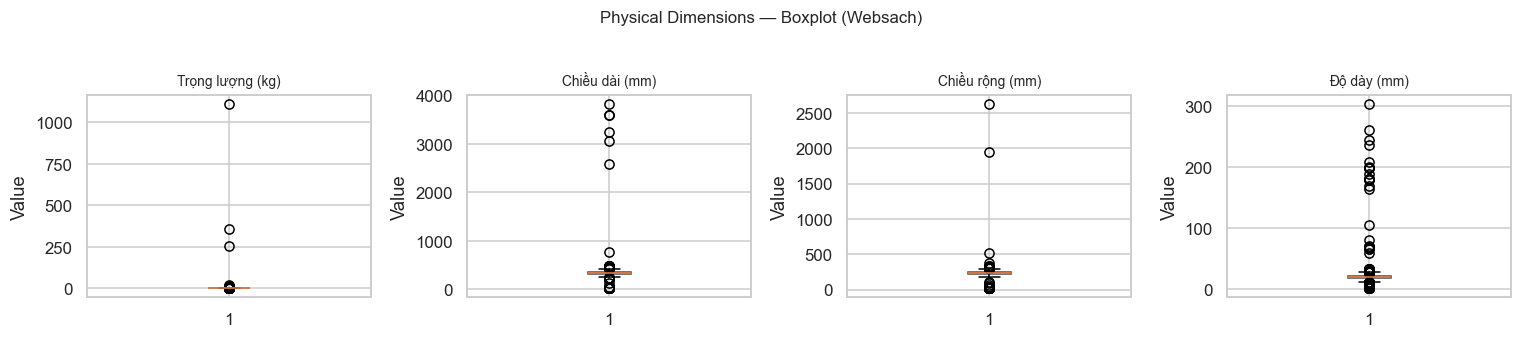

In [31]:
phys_cols = ['Trọng lượng (kg)', 'Chiều dài (mm)', 'Chiều rộng (mm)', 'Độ dày (mm)']
available_phys = [c for c in phys_cols if c in df.columns]

if available_phys:
    fig, axes = plt.subplots(1, len(available_phys), figsize=(14, 3))
    if len(available_phys) == 1:
        axes = [axes]
    for ax, col in zip(axes, available_phys):
        data = df[col].dropna()
        ax.boxplot(data, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='coral', alpha=0.7))
        ax.set_title(col, fontsize=9)
        ax.set_ylabel('Value')
    plt.suptitle('Physical Dimensions — Boxplot (Websach)', fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

### 7.6 Hệ điều hành

In [32]:
if 'Hệ điều hành' in df.columns:
    os_counts = df['Hệ điều hành'].value_counts()
    print(f"Hệ điều hành ({len(os_counts)} unique):")
    print(os_counts)

Hệ điều hành (63 unique):
Hệ điều hành
Windows 11 Home                            2491
Windows 10 Home                             938
FreeDOS                                     193
Windows 10                                  182
MacOS                                        85
                                           ... 
NO OS                                         1
Window 8.1                                    1
Windows 10/11 Bản quyền                       1
Windows 11 Home + Office Home & Student       1
Mac OS High Sierra                            1
Name: count, Length: 63, dtype: int64


In [33]:
# Cross-tab Hãng × Hệ điều hành — phát hiện anomaly (VD: Apple chạy Windows)
if 'Hãng sản xuất' in df.columns and 'Hệ điều hành' in df.columns:
    ct = pd.crosstab(
        df['Hãng sản xuất'],
        df['Hệ điều hành'].fillna('(missing)')
    )
    display(ct.style.background_gradient(cmap='YlOrRd', axis=None))


Hệ điều hành,AMD Radeon R5 M420,Asus,Chrome OS,Fedora,Free Dos,FreeDOS,Intel Core i7,Linux,Mac OS,Mac OS High Sierra,Mac OS X 10.12.5,MacOS,NO OS,Nhôm nguyên khối,Nhựa,No OS,No Os,NoOS,Non OS,OS No OS,OS Windows 11 Home,OS Windows 11 Home SL,Preinstalled macOS Mojave,Ubuntu,Unknown,Vỏ nhựa,Window 11,Window 11 bản quyền,Window 8.1,Windows,Windows 10,Windows 10 Home,Windows 10 Pro,Windows 10 Pro / Windows 11 Pro,Windows 10/11 Bản quyền,Windows 11,Windows 11 Home,Windows 11 Home + Microsoft 365 Basic + Office Home 2024,Windows 11 Home + Microsoft Office Home and Student,Windows 11 Home + Office Home & Student,Windows 11 Home + Office Home 2024,Windows 11 Home SL,Windows 11 Home SL + Office Home & Student 2024 vĩnh viễn + Microsoft 365 Basic,Windows 11 Home SL + Office Trial,Windows 11 Home Single,Windows 11 Home Single Language,Windows 11 Home Single Language 64-bit + Office Home 2024,Windows 11 Home Single Language bản quyền,"Windows 11 Home Single Language, English + Microsoft 365 Basic + Office Home 2024",Windows 11 Home bản quyền,Windows 11 Pro,Windows 11 Pro 64bit,Windows 11 Pro bản quyền,Windows 11 SL,Windows 11 bản quyền,Windows 7,Windows 8.1,macOS,macOS High Sierra,macOS Sequoia,macOS Tahoe
Hãng sản xuất,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Acer,0,0,0,0,0,12,0,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,119,1,0,0,0,170,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
Aorus,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Apple,0,0,0,0,0,0,0,0,40,1,1,74,0,0,0,0,0,0,0,0,0,0,1,0,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,1,5,13
Asus,1,1,0,0,0,0,0,2,0,0,0,0,0,0,0,3,1,0,0,0,0,0,0,0,31,1,1,0,0,0,145,164,0,0,1,4,435,0,0,0,0,6,0,0,0,0,0,0,0,2,1,0,0,0,1,0,1,0,0,0,0
Avita,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Chuwi,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Dell,0,0,0,7,0,46,1,6,0,0,0,0,0,1,1,1,0,2,0,0,0,0,0,12,3,0,0,1,0,0,0,256,19,0,0,4,434,0,1,1,0,0,1,0,0,0,1,0,0,0,3,0,0,2,0,0,2,0,0,0,0
Fujitsu,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Gigabyte,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,2,0,0,0,0,48,0,0,0,0,1,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0


---
## 8. Duplicate Check

Kiểm tra duplicate theo `source_url` (unique identifier của Websach) và theo spec tổng hợp.

In [34]:
# Duplicate theo URL
if 'source_url' in df.columns:
    n_dup_url = df['source_url'].duplicated().sum()
    print(f"Duplicate source_url: {n_dup_url} / {len(df)}")
    if n_dup_url > 0:
        dup_urls = df[df['source_url'].duplicated(keep=False)]
        display(dup_urls[['Hãng sản xuất', 'source_url', 'shop_1_price']].head(10))

Duplicate source_url: 0 / 4384


In [35]:
# Duplicate theo full row
n_dup_full = df.duplicated().sum()
print(f"Duplicate full rows: {n_dup_full} / {len(df)}")

Duplicate full rows: 0 / 4384


In [36]:
# Duplicate theo spec chính (không tính URL và giá shop)
spec_key_cols = [
    'Hãng sản xuất', 'Loại CPU', 'Dung lượng RAM',
    'Dung lượng ổ cứng (GB)', 'Kích thước (inch)'
]
available_key = [c for c in spec_key_cols if c in df.columns]

if available_key:
    n_dup_spec = df[available_key].duplicated().sum()
    print(f"Duplicate theo spec key ({available_key}): {n_dup_spec} / {len(df)}")
    # Note: spec duplicate không nhất thiết là lỗi — cùng config nhưng khác màu/shop

Duplicate theo spec key (['Hãng sản xuất', 'Loại CPU', 'Dung lượng RAM', 'Dung lượng ổ cứng (GB)', 'Kích thước (inch)']): 1704 / 4384


---
## 9. Issues Summary & Cleaning Checklist

Tổng hợp tất cả vấn đề phát hiện trong quá trình inspection. Đây là input trực tiếp cho `02b_websach_cleaning.ipynb`.

### 💰 Giá (Price)
- [ ] Dùng `median(shop_1, shop_2, shop_3)` → cột `price`
- [ ] Drop rows không có bất kỳ giá nào (`n_prices == 0`)
- [ ] Drop outlier giá theo domain knowledge: giá < 3M hoặc > 500M → xem xét drop
- [ ] Kiểm tra lại các case có spread giá bất thường giữa các shop

### ❓ Missing Values
- [ ] Cột missing > 60% (Critical): cân nhắc drop hoặc thêm indicator column
  - Loại Pin, Dung lượng VGA, Hỗ trợ RAM tối đa, Chất liệu vỏ...
- [ ] Cột missing 30–60% (High): impute bằng mode hoặc `'Unknown'`
- [ ] Cột missing < 10% (Low): impute hoặc drop rows tùy context

### 📊 Outlier — Numeric
- [ ] Trọng lượng (kg): loại bỏ giá trị > 10 kg (domain: laptop ≤ 5 kg)
- [ ] Kích thước màn hình: loại bỏ giá trị > 25 inch
- [ ] Chiều dài/rộng/dày: lọc theo domain knowledge (mm)
- [ ] CPU speed: kiểm tra values > 10 GHz

### 🔤 Categorical — Chuẩn hoá
- [ ] Strip trailing whitespace tất cả cột object
- [ ] Chuẩn hoá `Hãng sản xuất`: case, alias (`'ASUS'` vs `'Asus'`)
- [ ] Chuẩn hoá `Hệ điều hành`: gom nhóm (Windows 11/10/S → Windows, v.v.)
- [ ] Chuẩn hoá `Kiểu card đồ họa`: integrated / discrete
- [ ] Kiểm tra `Công nghệ CPU`: Intel / AMD / Apple M-series

### 🔁 Duplicates
- [ ] Drop duplicate theo `source_url` (nếu có)
- [ ] Không tự động drop duplicate theo spec (cùng config ≠ cùng sản phẩm)

### 🔗 Chuẩn bị cho Merge (notebook 03)
- [ ] Tạo cột `source = 'websach'`
- [ ] Rename columns → snake_case tiếng Anh:
  - `Hãng sản xuất` → `brand`
  - `Dung lượng RAM` → `ram_gb`
  - `Dung lượng ổ cứng (GB)` → `storage_gb`
  - `Kích thước (inch)` → `screen_size_inch`
  - `Trọng lượng (kg)` → `weight_kg`
  - `Loại CPU` → `cpu_type`
  - `Tốc độ CPU (GHz)` → `cpu_speed_ghz`
  - `Kiểu card đồ họa` → `gpu_type`
  - `Hệ điều hành` → `os`
  - `price_median` → `price`
- [ ] Export: `data/processed/websach_clean.csv`


In [37]:
# Snapshot cuối — thống kê nhanh sau inspection
print("=" * 60)
print(f"Dataset: Websach — {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Cột có missing: {(df.isnull().sum() > 0).sum()} / {df.shape[1]}")
print(f"Cột numeric: {len(df.select_dtypes(include='number').columns)}")
print(f"Cột object: {len(df.select_dtypes(include='object').columns)}")
print(f"Giá median (triệu): {df['price_median'].median()/1e6:.1f}M" if 'price_median' in df.columns else "")
print("=" * 60)

Dataset: Websach — 4,384 rows × 44 cols
Cột có missing: 31 / 44
Cột numeric: 14
Cột object: 30



In [38]:
# ✅ Sanity checks — đảm bảo notebook chạy end-to-end không bị vỡ
assert len(df) > 0, "DataFrame rỗng!"
assert 'Hãng sản xuất' in df.columns, "Thiếu cột 'Hãng sản xuất'!"
assert price_median.notna().sum() > 0, "Không có giá hợp lệ nào!"
assert df.select_dtypes(include='number').shape[1] > 0, "Không có cột số nào!"

n_complete = (df.isnull().sum(axis=1) == 0).sum()
print(f"✅ Tất cả sanity checks passed.")
print(f"   Rows hoàn chỉnh (0 missing): {n_complete:,} / {len(df):,} ({n_complete/len(df)*100:.1f}%)")


✅ Tất cả sanity checks passed.
   Rows hoàn chỉnh (0 missing): 110 / 4,384 (2.5%)
